In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

sns.set_theme(style="whitegrid")

df = pd.read_csv(
    "../data/restaurant_business_intelligence.csv"
)

print("Dataset shape:", df.shape)

display(df.head())

Dataset shape: (7403, 33)


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes,Log Votes,Rating Score,Popularity Score,Performance Score,Performance Segment,Digital Adoption,Value Score,Performance_Normalized,Value_Normalized,Popularity_Normalized,Digital_Score,Opportunity Score
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",1100.0,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314,5.752573,0.967742,0.538749,0.796145,High Performer,One Service,0.977009,0.786585,0.967175,0.538749,0.5,0.748207
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,1200.0,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591,6.383507,0.870968,0.620792,0.770897,High Performer,One Service,0.909230,0.757381,0.870399,0.620792,0.5,0.725362
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",4000.0,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270,5.602119,0.838710,0.519185,0.710900,High Performer,One Service,0.885599,0.687981,0.836659,0.519185,0.5,0.670628
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",1500.0,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365,5.902633,1.000000,0.558262,0.823305,High Performer,Neither,0.999440,0.818002,0.999202,0.558262,0.0,0.697714
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",1500.0,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229,5.438079,0.967742,0.497854,0.779787,High Performer,One Service,0.976859,0.767664,0.966961,0.497854,0.5,0.733342


In [2]:

customer_columns = [
    "Restaurant Name",
    "City",
    "Cuisines",
    "Aggregate rating",
    "Rating text",
    "Votes",
    "Average Cost for two",
    "Price range",
    "Has Online delivery",
    "Has Table booking"
]

for col in customer_columns:
    print(
        f"{col}: {'OK' if col in df.columns else 'MISSING'}"
    )

Restaurant Name: OK
City: OK
Cuisines: OK
Aggregate rating: OK
Rating text: OK
Votes: OK
Average Cost for two: OK
Price range: OK
Has Online delivery: OK
Has Table booking: OK


In [3]:

top_engagement = (
    df[
        [
            "Restaurant Name",
            "City",
            "Cuisines",
            "Aggregate rating",
            "Votes",
            "Performance Score"
        ]
    ]
    .sort_values(
        "Votes",
        ascending=False
    )
    .head(20)
)

display(top_engagement)

,Restaurant Name,City,Cuisines,Aggregate rating,Votes,Performance Score
720,Toit,Bangalore,"Italian, American, Pizza",4.8,10934,0.980645
727,Truffles,Bangalore,"American, Burger, Cafe",4.7,9667,0.954885
3374,Hauz Khas Social,New Delhi,"Continental, American, Asian, North Indian",4.3,7931,0.867171
2074,Peter Cat,Kolkata,"Continental, North Indian",4.3,7574,0.864776
731,AB's - Absolute Barbecues,Bangalore,"European, Mediterranean, North Indian",4.6,6907,0.918046
2076,Barbeque Nation,Kolkata,"North Indian, Chinese",4.9,5966,0.968494
735,Big Brewsky,Bangalore,"Finger Food, North Indian, Italian, Continenta...",4.5,5705,0.888748
1969,AB's - Absolute Barbecues,Hyderabad,"European, Mediterranean, North Indian",4.9,5434,0.963637
728,The Black Pearl,Bangalore,"North Indian, European, Mediterranean",4.1,5385,0.808327
2073,BarBQ,Kolkata,"Chinese, North Indian",4.2,5288,0.826737


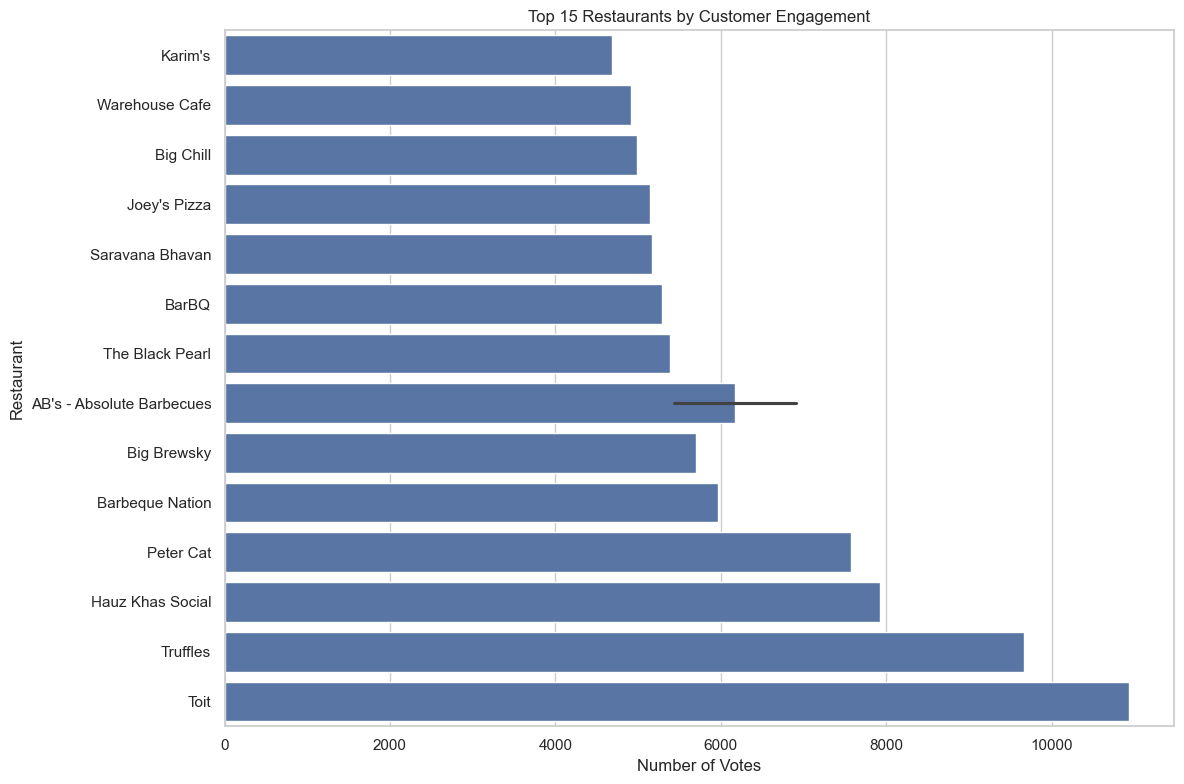

In [4]:
plt.figure(figsize=(12, 8))

plot_data = (
    top_engagement
    .head(15)
    .sort_values("Votes")
)

sns.barplot(
    data=plot_data,
    x="Votes",
    y="Restaurant Name"
)

plt.title("Top 15 Restaurants by Customer Engagement")
plt.xlabel("Number of Votes")
plt.ylabel("Restaurant")

plt.tight_layout()
plt.show()

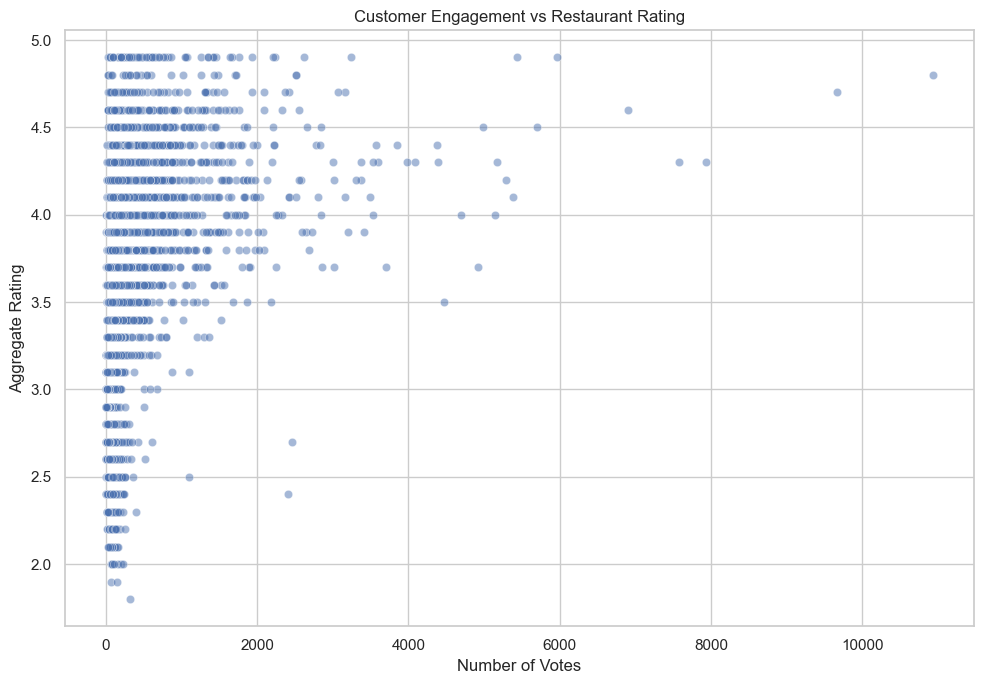

In [5]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="Votes",
    y="Aggregate rating",
    alpha=0.5
)

plt.title("Customer Engagement vs Restaurant Rating")
plt.xlabel("Number of Votes")
plt.ylabel("Aggregate Rating")

plt.tight_layout()
plt.show()

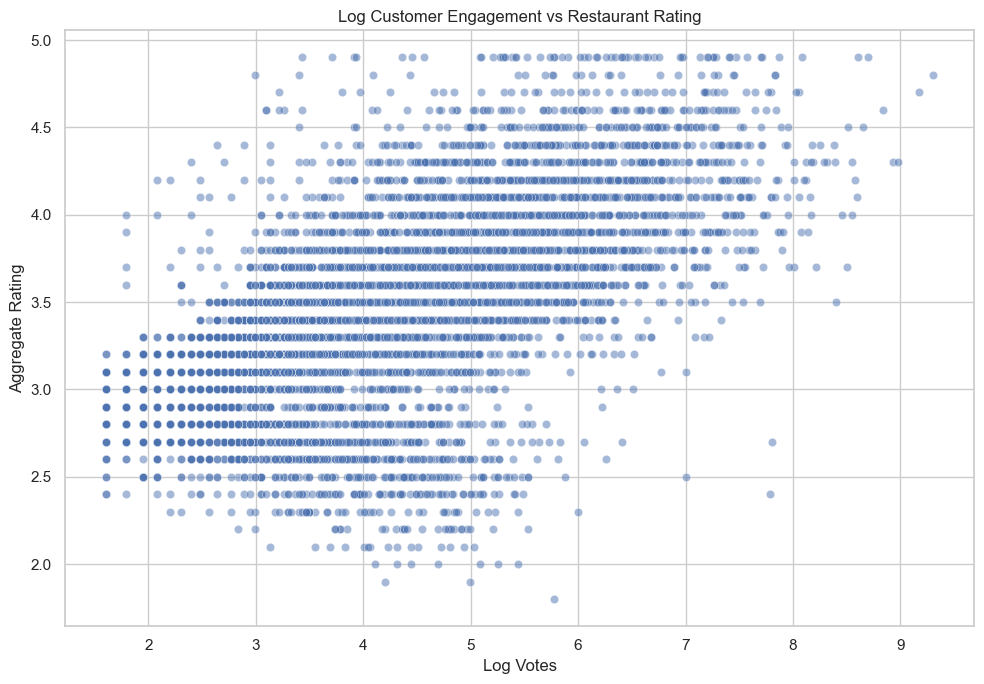

In [6]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="Log Votes",
    y="Aggregate rating",
    alpha=0.5
)

plt.title("Log Customer Engagement vs Restaurant Rating")
plt.xlabel("Log Votes")
plt.ylabel("Aggregate Rating")

plt.tight_layout()
plt.show()

In [7]:
engagement_correlation = (
    df["Votes"]
    .corr(df["Aggregate rating"])
)

print(
    f"Correlation between Votes and Rating: "
    f"{engagement_correlation:.3f}"
)

Correlation between Votes and Rating: 0.409


In [8]:

rating_text_counts = (
    df["Rating text"]
    .value_counts()
    .reset_index()
)

rating_text_counts.columns = [
    "Rating Text",
    "Restaurant Count"
]

rating_text_counts

,Rating Text,Restaurant Count
0,Average,3737
1,Good,2100
2,Very Good,1079
3,Excellent,301
4,Poor,186


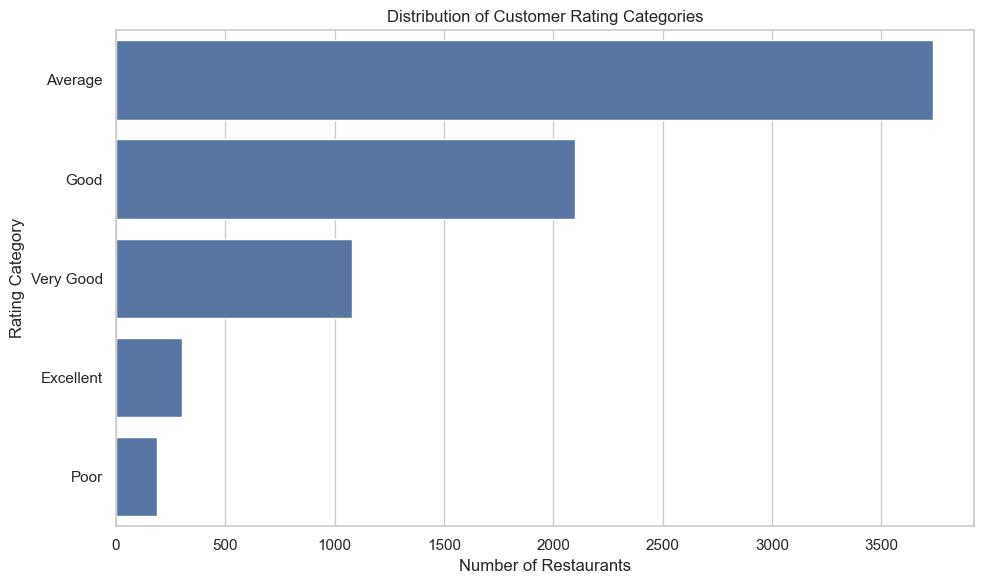

In [9]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=rating_text_counts,
    x="Restaurant Count",
    y="Rating Text"
)

plt.title("Distribution of Customer Rating Categories")
plt.xlabel("Number of Restaurants")
plt.ylabel("Rating Category")

plt.tight_layout()
plt.show()

In [10]:
rating_distribution = (
    df[df["Aggregate rating"] > 0]
    ["Aggregate rating"]
    .value_counts()
    .sort_index()
)

rating_distribution

Aggregate rating
1.8      1
1.9      2
2.0      7
2.1     15
2.2     27
2.3     47
2.4     87
2.5    110
2.6    191
2.7    250
2.8    315
2.9    381
3.0    468
3.1    519
3.2    522
3.3    483
3.4    498
3.5    480
3.6    458
3.7    427
3.8    400
3.9    335
4.0    266
4.1    274
4.2    221
4.3    174
4.4    144
4.5     95
4.6     78
4.7     42
4.8     25
4.9     61
Name: count, dtype: int64

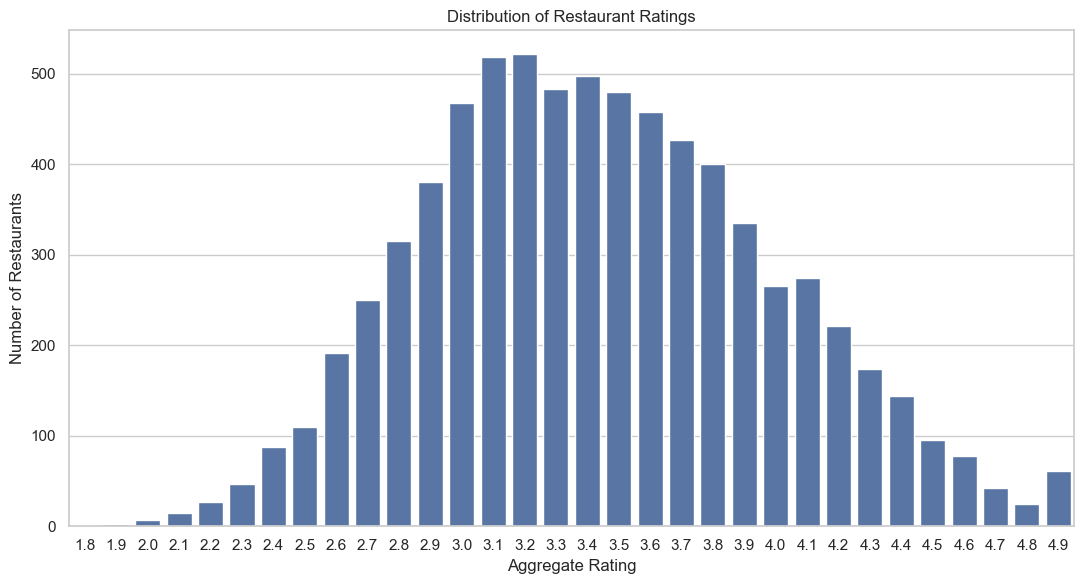

In [11]:
plt.figure(figsize=(11, 6))

sns.barplot(
    x=rating_distribution.index,
    y=rating_distribution.values
)

plt.title("Distribution of Restaurant Ratings")
plt.xlabel("Aggregate Rating")
plt.ylabel("Number of Restaurants")

plt.tight_layout()
plt.show()

In [12]:
price_customer_behavior = (
    df
    .groupby("Price range")
    .agg(
        Restaurant_Count=("Restaurant Name", "count"),
        Average_Rating=("Aggregate rating", "mean"),
        Average_Votes=("Votes", "mean"),
        Total_Votes=("Votes", "sum")
    )
    .reset_index()
)

price_customer_behavior

,Price range,Restaurant_Count,Average_Rating,Average_Votes,Total_Votes
0,1,2744,3.238885,71.713192,196781
1,2,2711,3.377167,169.347473,459101
2,3,1373,3.777276,455.142025,624910
3,4,575,3.890957,375.624348,215984


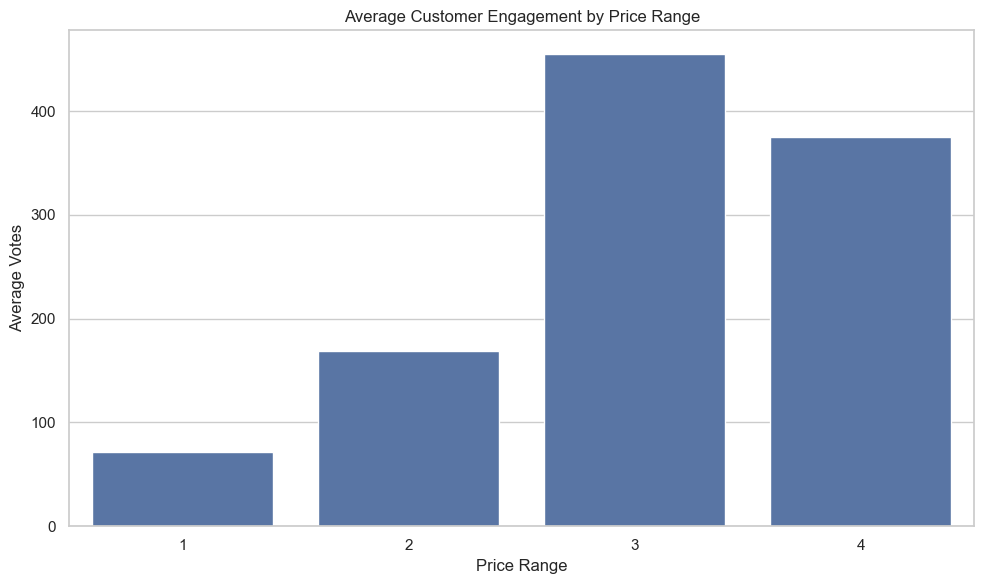

In [13]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=price_customer_behavior,
    x="Price range",
    y="Average_Votes"
)

plt.title("Average Customer Engagement by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Average Votes")

plt.tight_layout()
plt.show()

In [ ]:

customer_cuisine = df[
    [
        "Restaurant Name",
        "Cuisines",
        "Aggregate rating",
        "Votes"
    ]
].dropna(subset=["Cuisines"]).copy()

customer_cuisine["Cuisines"] = (
    customer_cuisine["Cuisines"]
    .str.split(", ")
)

customer_cuisine = customer_cuisine.explode("Cuisines")

cuisine_customer_behavior = (
    customer_cuisine
    .groupby("Cuisines")
    .agg(
        Restaurant_Count=("Restaurant Name", "count"),
        Average_Rating=("Aggregate rating", "mean"),
        Average_Votes=("Votes", "mean"),
        Total_Votes=("Votes", "sum")
    )
    .reset_index()
)

cuisine_customer_filtered = (
    cuisine_customer_behavior[
        cuisine_customer_behavior["Restaurant_Count"] >= 20
    ]
    .sort_values(
        "Average_Votes",
        ascending=False
    )
)

cuisine_customer_filtered.head(20)

,Cuisines,Restaurant_Count,Average_Rating,Average_Votes,Total_Votes
86,Mediterranean,110,4.020000,732.109091,80532
47,European,146,3.964384,707.568493,103305
122,Southern,24,4.129167,580.791667,13939
55,Goan,20,3.970000,574.400000,11488
2,American,380,3.757895,481.857895,183106
140,Vegetarian,23,4.073913,465.826087,10714
7,Asian,228,3.898684,457.447368,104298
69,Italian,726,3.748485,453.484848,329230
114,Sandwich,53,4.066038,443.396226,23500
116,Seafood,171,3.929825,434.233918,74254


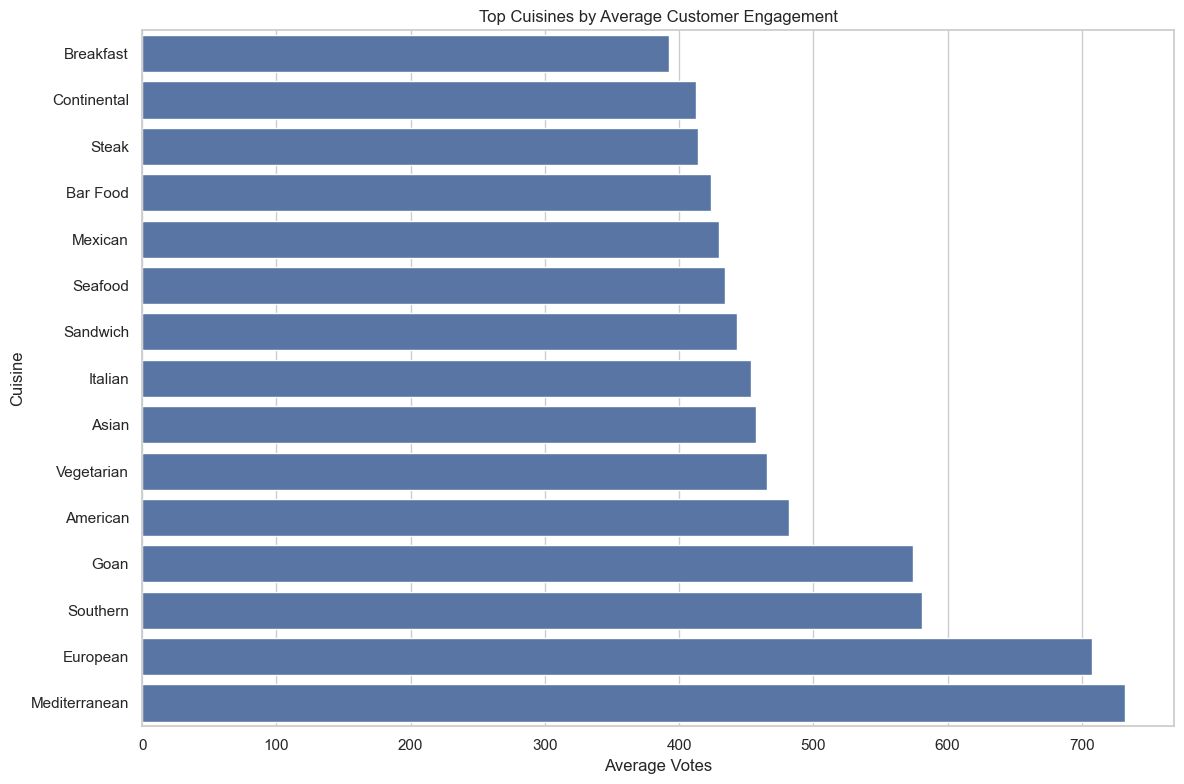

In [15]:
plt.figure(figsize=(12, 8))

plot_cuisine = (
    cuisine_customer_filtered
    .head(15)
    .sort_values("Average_Votes")
)

sns.barplot(
    data=plot_cuisine,
    x="Average_Votes",
    y="Cuisines"
)

plt.title("Top Cuisines by Average Customer Engagement")
plt.xlabel("Average Votes")
plt.ylabel("Cuisine")

plt.tight_layout()
plt.show()

In [16]:

q1 = df["Votes"].quantile(0.25)
q3 = df["Votes"].quantile(0.75)

print("25th percentile:", q1)
print("75th percentile:", q3)

25th percentile: 19.0
75th percentile: 181.0


In [17]:
def classify_engagement(votes):
    if votes <= q1:
        return "Low Engagement"
    elif votes <= q3:
        return "Moderate Engagement"
    else:
        return "High Engagement"


df["Customer Engagement Segment"] = (
    df["Votes"]
    .apply(classify_engagement)
)

df["Customer Engagement Segment"].value_counts()

Customer Engagement Segment
Moderate Engagement    3639
Low Engagement         1915
High Engagement        1849
Name: count, dtype: int64

In [18]:
engagement_segments = (
    df
    .groupby("Customer Engagement Segment")
    .agg(
        Restaurant_Count=("Restaurant Name", "count"),
        Average_Rating=("Aggregate rating", "mean"),
        Average_Votes=("Votes", "mean"),
        Average_Performance=("Performance Score", "mean")
    )
    .reset_index()
)

engagement_segments

,Customer Engagement Segment,Restaurant_Count,Average_Rating,Average_Votes,Average_Performance
0,High Engagement,1849,3.956842,655.199567,0.653171
1,Low Engagement,1915,3.022037,10.168146,0.273733
2,Moderate Engagement,3639,3.397389,73.053037,0.439538


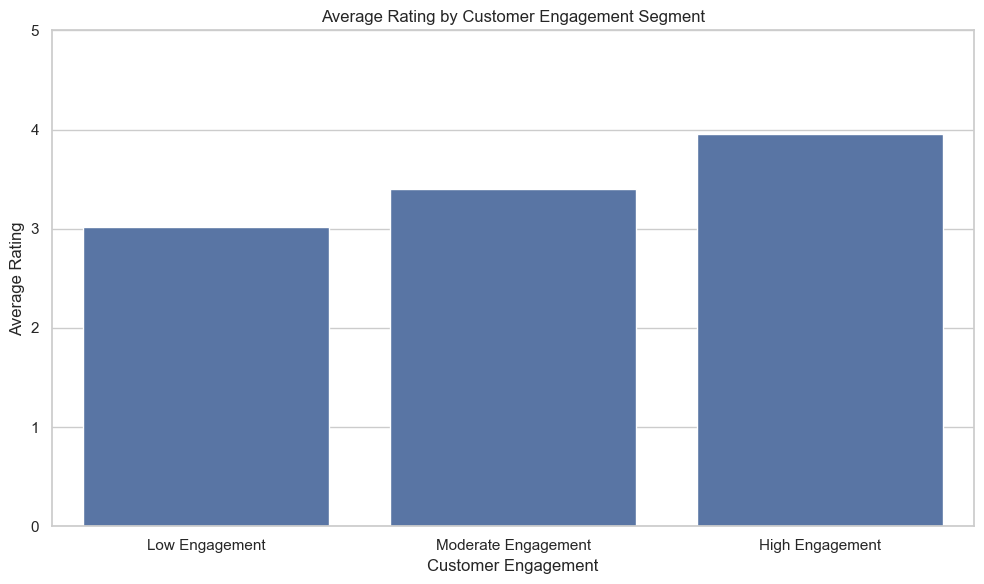

In [19]:
plt.figure(figsize=(10, 6))

order = [
    "Low Engagement",
    "Moderate Engagement",
    "High Engagement"
]

sns.barplot(
    data=engagement_segments,
    x="Customer Engagement Segment",
    y="Average_Rating",
    order=order
)

plt.title("Average Rating by Customer Engagement Segment")
plt.xlabel("Customer Engagement")
plt.ylabel("Average Rating")

plt.ylim(0, 5)
plt.tight_layout()
plt.show()

In [20]:
high_engagement = (
    df[
        df["Customer Engagement Segment"] == "High Engagement"
    ]
    .sort_values("Votes", ascending=False)
    [
        [
            "Restaurant Name",
            "City",
            "Cuisines",
            "Aggregate rating",
            "Votes",
            "Performance Score"
        ]
    ]
    .head(25)
)

display(high_engagement)

,Restaurant Name,City,Cuisines,Aggregate rating,Votes,Performance Score
720,Toit,Bangalore,"Italian, American, Pizza",4.8,10934,0.980645
727,Truffles,Bangalore,"American, Burger, Cafe",4.7,9667,0.954885
3374,Hauz Khas Social,New Delhi,"Continental, American, Asian, North Indian",4.3,7931,0.867171
2074,Peter Cat,Kolkata,"Continental, North Indian",4.3,7574,0.864776
731,AB's - Absolute Barbecues,Bangalore,"European, Mediterranean, North Indian",4.6,6907,0.918046
2076,Barbeque Nation,Kolkata,"North Indian, Chinese",4.9,5966,0.968494
735,Big Brewsky,Bangalore,"Finger Food, North Indian, Italian, Continenta...",4.5,5705,0.888748
1969,AB's - Absolute Barbecues,Hyderabad,"European, Mediterranean, North Indian",4.9,5434,0.963637
728,The Black Pearl,Bangalore,"North Indian, European, Mediterranean",4.1,5385,0.808327
2073,BarBQ,Kolkata,"Chinese, North Indian",4.2,5288,0.826737


In [21]:
rating_median = df["Aggregate rating"].median()

customer_favorites = df[
    (df["Customer Engagement Segment"] == "High Engagement") &
    (df["Aggregate rating"] >= rating_median)
].copy()

customer_favorites = (
    customer_favorites
    .sort_values(
        ["Votes", "Aggregate rating"],
        ascending=[False, False]
    )
    [
        [
            "Restaurant Name",
            "City",
            "Cuisines",
            "Aggregate rating",
            "Votes",
            "Performance Score"
        ]
    ]
    .head(25)
)

display(customer_favorites)

,Restaurant Name,City,Cuisines,Aggregate rating,Votes,Performance Score
720,Toit,Bangalore,"Italian, American, Pizza",4.8,10934,0.980645
727,Truffles,Bangalore,"American, Burger, Cafe",4.7,9667,0.954885
3374,Hauz Khas Social,New Delhi,"Continental, American, Asian, North Indian",4.3,7931,0.867171
2074,Peter Cat,Kolkata,"Continental, North Indian",4.3,7574,0.864776
731,AB's - Absolute Barbecues,Bangalore,"European, Mediterranean, North Indian",4.6,6907,0.918046
2076,Barbeque Nation,Kolkata,"North Indian, Chinese",4.9,5966,0.968494
735,Big Brewsky,Bangalore,"Finger Food, North Indian, Italian, Continenta...",4.5,5705,0.888748
1969,AB's - Absolute Barbecues,Hyderabad,"European, Mediterranean, North Indian",4.9,5434,0.963637
728,The Black Pearl,Bangalore,"North Indian, European, Mediterranean",4.1,5385,0.808327
2073,BarBQ,Kolkata,"Chinese, North Indian",4.2,5288,0.826737


In [22]:
df.to_csv(
    "../data/restaurant_customer_analysis.csv",
    index=False
)

print("Customer analysis dataset saved successfully!")
print("Shape:", df.shape)

Customer analysis dataset saved successfully!
Shape: (7403, 34)


In [23]:
digital_customer_behavior = (
    df
    .groupby("Digital Adoption")
    .agg(
        Restaurant_Count=("Restaurant Name", "count"),
        Average_Rating=("Aggregate rating", "mean"),
        Average_Votes=("Votes", "mean"),
        Total_Votes=("Votes", "sum"),
        Average_Performance=("Performance Score", "mean")
    )
    .reset_index()
)

display(digital_customer_behavior)

,Digital Adoption,Restaurant_Count,Average_Rating,Average_Votes,Total_Votes,Average_Performance
0,Both Services,433,3.612471,476.491917,206321,0.553641
1,Neither,4370,3.451259,177.683982,776479,0.439158
2,One Service,2600,3.392423,197.683077,513976,0.450978


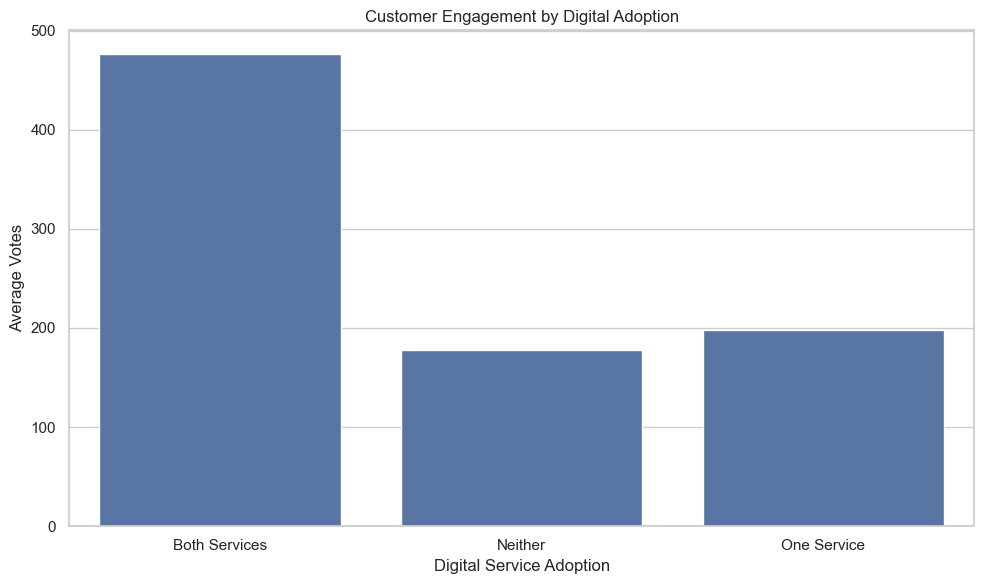

In [24]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=digital_customer_behavior,
    x="Digital Adoption",
    y="Average_Votes"
)

plt.title("Customer Engagement by Digital Adoption")
plt.xlabel("Digital Service Adoption")
plt.ylabel("Average Votes")

plt.tight_layout()
plt.show()

In [25]:
delivery_analysis = (
    df
    .groupby("Has Online delivery")
    .agg(
        Restaurant_Count=("Restaurant Name", "count"),
        Average_Rating=("Aggregate rating", "mean"),
        Average_Votes=("Votes", "mean"),
        Average_Performance=("Performance Score", "mean")
    )
    .reset_index()
)

display(delivery_analysis)

,Has Online delivery,Restaurant_Count,Average_Rating,Average_Votes,Average_Performance
0,No,5048,3.467433,193.940174,0.447923
1,Yes,2355,3.381274,219.858174,0.454469


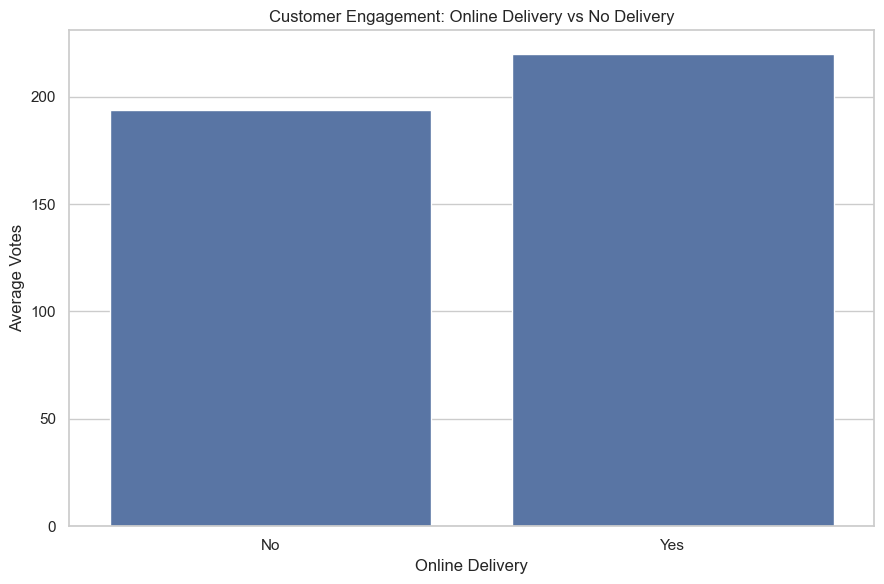

In [26]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=delivery_analysis,
    x="Has Online delivery",
    y="Average_Votes"
)

plt.title("Customer Engagement: Online Delivery vs No Delivery")
plt.xlabel("Online Delivery")
plt.ylabel("Average Votes")

plt.tight_layout()
plt.show()

In [27]:
booking_analysis = (
    df
    .groupby("Has Table booking")
    .agg(
        Restaurant_Count=("Restaurant Name", "count"),
        Average_Rating=("Aggregate rating", "mean"),
        Average_Votes=("Votes", "mean"),
        Average_Performance=("Performance Score", "mean")
    )
    .reset_index()
)

display(booking_analysis)

,Has Table booking,Restaurant_Count,Average_Rating,Average_Votes,Average_Performance
0,No,6292,3.413970,172.905912,0.437010
1,Yes,1111,3.587579,368.003600,0.523603


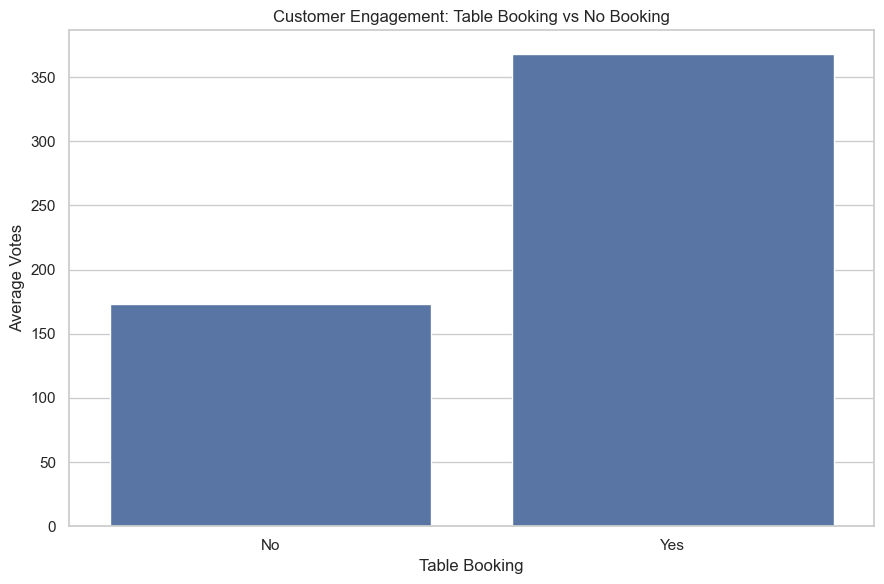

In [28]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=booking_analysis,
    x="Has Table booking",
    y="Average_Votes"
)

plt.title("Customer Engagement: Table Booking vs No Booking")
plt.xlabel("Table Booking")
plt.ylabel("Average Votes")

plt.tight_layout()
plt.show()

In [29]:
digital_summary = (
    df
    .groupby("Digital Adoption")
    .agg(
        Restaurants=("Restaurant Name", "count"),
        Avg_Rating=("Aggregate rating", "mean"),
        Avg_Votes=("Votes", "mean"),
        Avg_Performance=("Performance Score", "mean"),
        Avg_Opportunity=("Opportunity Score", "mean")
    )
    .reset_index()
)

display(digital_summary)

,Digital Adoption,Restaurants,Avg_Rating,Avg_Votes,Avg_Performance,Avg_Opportunity
0,Both Services,433,3.612471,476.491917,0.553641,0.603813
1,Neither,4370,3.451259,177.683982,0.439158,0.349856
2,One Service,2600,3.392423,197.683077,0.450978,0.435993


In [30]:
df.to_csv(
    "../data/restaurant_customer_analysis.csv",
    index=False
)

print("Customer analysis dataset saved successfully!")
print("Shape:", df.shape)

Customer analysis dataset saved successfully!
Shape: (7403, 34)


In [31]:
rating_threshold = df["Aggregate rating"].median()
votes_threshold = df["Votes"].median()

print("Rating threshold:", rating_threshold)
print("Votes threshold:", votes_threshold)

Rating threshold: 3.4
Votes threshold: 60.0


In [32]:
def customer_opportunity(row):
    high_rating = row["Aggregate rating"] >= rating_threshold
    high_engagement = row["Votes"] >= votes_threshold

    if high_rating and high_engagement:
        return "Customer Favorite"

    elif high_rating and not high_engagement:
        return "Hidden Potential"

    elif not high_rating and high_engagement:
        return "Needs Improvement"

    else:
        return "Low Engagement"


df["Customer Opportunity"] = df.apply(
    customer_opportunity,
    axis=1
)

print(df["Customer Opportunity"].value_counts())

Customer Opportunity
Customer Favorite    3043
Low Engagement       2761
Hidden Potential      935
Needs Improvement     664
Name: count, dtype: int64


In [33]:
customer_opportunity_summary = (
    df
    .groupby("Customer Opportunity")
    .agg(
        Restaurant_Count=("Restaurant Name", "count"),
        Average_Rating=("Aggregate rating", "mean"),
        Average_Votes=("Votes", "mean"),
        Average_Cost=("Average Cost for two", "mean"),
        Average_Performance=("Performance Score", "mean"),
        Average_Opportunity=("Opportunity Score", "mean")
    )
    .reset_index()
)

display(customer_opportunity_summary)

,Customer Opportunity,Restaurant_Count,Average_Rating,Average_Votes,Average_Cost,Average_Performance,Average_Opportunity
0,Customer Favorite,3043,3.921919,431.901742,2701.179420,0.614603,0.551054
1,Hidden Potential,935,3.629947,34.451337,754.166846,0.451765,0.393047
2,Low Engagement,2761,2.974719,18.540022,484.523551,0.285579,0.233982
3,Needs Improvement,664,2.898946,149.243976,745.082831,0.376912,0.355239


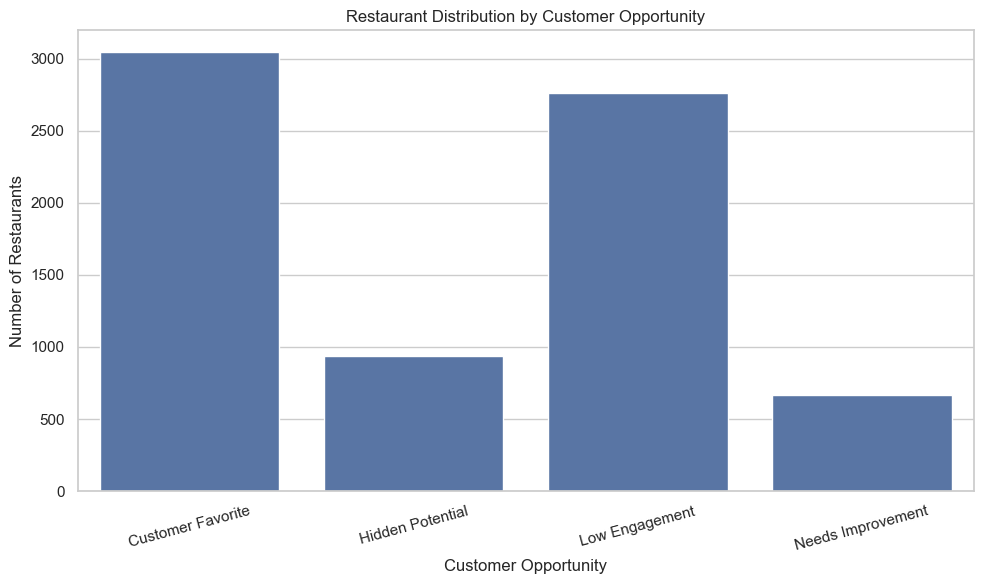

In [34]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=customer_opportunity_summary,
    x="Customer Opportunity",
    y="Restaurant_Count"
)

plt.title("Restaurant Distribution by Customer Opportunity")
plt.xlabel("Customer Opportunity")
plt.ylabel("Number of Restaurants")

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [35]:
customer_favorites_final = (
    df[
        df["Customer Opportunity"] == "Customer Favorite"
    ]
    .sort_values(
        ["Votes", "Aggregate rating"],
        ascending=[False, False]
    )
    [
        [
            "Restaurant Name",
            "City",
            "Cuisines",
            "Aggregate rating",
            "Votes",
            "Average Cost for two",
            "Performance Score",
            "Opportunity Score"
        ]
    ]
    .head(25)
)

display(customer_favorites_final)

,Restaurant Name,City,Cuisines,Aggregate rating,Votes,Average Cost for two,Performance Score,Opportunity Score
720,Toit,Bangalore,"Italian, American, Pizza",4.8,10934,2000.0,0.980645,0.840008
727,Truffles,Bangalore,"American, Burger, Cafe",4.7,9667,800.0,0.954885,0.891897
3374,Hauz Khas Social,New Delhi,"Continental, American, Asian, North Indian",4.3,7931,1600.0,0.867171,0.887421
2074,Peter Cat,Kolkata,"Continental, North Indian",4.3,7574,1000.0,0.864776,0.810350
731,AB's - Absolute Barbecues,Bangalore,"European, Mediterranean, North Indian",4.6,6907,1400.0,0.918046,0.783472
2076,Barbeque Nation,Kolkata,"North Indian, Chinese",4.9,5966,1600.0,0.968494,0.829072
735,Big Brewsky,Bangalore,"Finger Food, North Indian, Italian, Continenta...",4.5,5705,1800.0,0.888748,0.906903
1969,AB's - Absolute Barbecues,Hyderabad,"European, Mediterranean, North Indian",4.9,5434,1500.0,0.963637,0.824693
728,The Black Pearl,Bangalore,"North Indian, European, Mediterranean",4.1,5385,1400.0,0.808327,0.759218
2073,BarBQ,Kolkata,"Chinese, North Indian",4.2,5288,900.0,0.826737,0.775951


In [36]:
hidden_potential = (
    df[
        df["Customer Opportunity"] == "Hidden Potential"
    ]
    .sort_values(
        ["Aggregate rating", "Votes"],
        ascending=[False, False]
    )
    [
        [
            "Restaurant Name",
            "City",
            "Cuisines",
            "Aggregate rating",
            "Votes",
            "Average Cost for two",
            "Digital Adoption",
            "Opportunity Score"
        ]
    ]
    .head(25)
)

display(hidden_potential)

,Restaurant Name,City,Cuisines,Aggregate rating,Votes,Average Cost for two,Digital Adoption,Opportunity Score
842,The Great Indian Pub,Dehradun,North Indian,4.9,50,1500.0,Neither,0.604958
49,Garota de Ipanema,Rio de Janeiro,"Brazilian, Bar Food",4.9,49,120.0,Neither,0.604248
47,Braseiro da G��vea,Rio de Janeiro,"Brazilian, Bar Food",4.9,40,100.0,Neither,0.594911
38,Coco Bambu,Bras�_lia,International,4.9,30,230.0,Neither,0.581732
64,Skye - Hotel Unique,S��o Paulo,"Beverages, International",4.8,59,300.0,Neither,0.595292
42,Confeitaria Colombo,Rio de Janeiro,"Desserts, Cafe",4.8,29,100.0,Neither,0.562701
46,TT Burger,Rio de Janeiro,Burger,4.8,19,60.0,Neither,0.543625
2592,MOB Brewpub,New Delhi,"Continental, Italian, Asian, Indian",4.7,52,1500.0,Neither,0.571753
57,Apraz�_vel,Rio de Janeiro,Brazilian,4.7,44,300.0,Neither,0.564244
43,Bibi,Rio de Janeiro,"Juices, Healthy Food",4.7,24,60.0,Neither,0.536619


In [37]:
needs_improvement = (
    df[
        df["Customer Opportunity"] == "Needs Improvement"
    ]
    .sort_values(
        "Votes",
        ascending=False
    )
    [
        [
            "Restaurant Name",
            "City",
            "Cuisines",
            "Aggregate rating",
            "Votes",
            "Average Cost for two",
            "Digital Adoption",
            "Performance Score"
        ]
    ]
    .head(25)
)

display(needs_improvement)

,Restaurant Name,City,Cuisines,Aggregate rating,Votes,Average Cost for two,Digital Adoption,Performance Score
2588,My Bar Lounge & Restaurant,New Delhi,"North Indian, Chinese, Italian, Continental",2.7,2460,1000.0,Neither,0.496620
1119,The Wine Company,Gurgaon,"Italian, European",2.4,2412,2000.0,One Service,0.437531
3359,My Bar Grill,New Delhi,"North Indian, Italian, Continental, Chinese",3.3,1363,1200.0,Neither,0.582054
2587,Indian Coffee House,New Delhi,Fast Food,3.3,1300,200.0,Neither,0.579594
428,The Lady & Sons,Savannah,Southern,3.3,1201,40.0,Neither,0.575477
2582,Castle 9,New Delhi,"Finger Food, Continental, North Indian, Chinese",3.1,1099,1350.0,One Service,0.532155
2589,My Bar Square,New Delhi,"North Indian, Chinese, Italian, Continental",2.5,1096,1000.0,Neither,0.415884
6999,Le Cafe,Puducherry,Cafe,3.1,875,450.0,Neither,0.520312
1091,Fatburger,Gurgaon,"American, Mexican",3.3,793,1000.0,Both Services,0.553909
6945,Pind Balluchi,Noida,"North Indian, Mughlai",3.3,793,800.0,Both Services,0.553909


In [ ]:

df.to_csv(
    "../data/restaurant_customer_analysis.csv",
    index=False
)

print("Final Customer Analysis dataset saved successfully!")
print("Shape:", df.shape)

Final Customer Analysis dataset saved successfully!
Shape: (7403, 35)


In [39]:
print(
    "Customer Opportunity column:",
    "Customer Opportunity" in df.columns
)

print(
    "Customer Engagement Segment:",
    "Customer Engagement Segment" in df.columns
)

Customer Opportunity column: True
Customer Engagement Segment: True
